# Gist — dataset EDA

Where the evaluation data comes from, what is in it, and how the sample was drawn.

**Nothing here is reimplemented.** Every cell imports from the two selection
scripts and renders what they return:

- `scripts/analyse_videomme_subset.py` — describes the population and reconstructs
  how the original subset was drawn
- `scripts/build_videomme_pool.py` — buckets questions by modality and builds the
  balanced pool

One source of truth, two renderings: a markdown report for the repository, and
this notebook for a reader. Regenerate with
`uv run jupyter nbconvert --execute --inplace notebooks/01-dataset-eda.ipynb`.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# The scripts resolve .gist/ and data/ relative to the working directory, so run
# from the repository root rather than from notebooks/.
os.chdir(REPO)
sys.path.insert(0, str(REPO / "scripts"))

from analyse_videomme_subset import load_long_split, load_pool          # noqa: E402
from build_videomme_pool import load_long, select                       # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
ACCENT, MUTED = "#c2410c", "#d4d4d8"
pd.set_option("display.max_colwidth", 90)

## 1. The source

Video-MME ships as one table on HuggingFace, `lmms-lab/Video-MME`. Only the **long**
band is ever used: a two-minute clip cannot test compression on long video, so 600
of its 900 videos were never candidates.

In [2]:
raw = pd.read_parquet(REPO / "data/videomme-real-subset/hf/videomme/test-00000-of-00001.parquet")
bands = (raw.groupby("duration")
            .agg(videos=("video_id", "nunique"), questions=("video_id", "size"))
            .reindex(["short", "medium", "long"]))
bands["duration range"] = ["11 s – 2 min", "4 – 15 min", "30 – 60 min"]
bands

,videos,questions,duration range
duration,,,
short,300,900,11 s – 2 min
medium,300,900,4 – 15 min
long,300,900,30 – 60 min


In [3]:
long = load_long_split(REPO / "data/videomme-real-subset/hf/videomme/test-00000-of-00001.parquet")
print(f"long split: {long.video_id.nunique()} videos, {len(long)} questions, "
      f"video_id {long.video_id.astype(int).min()}–{long.video_id.astype(int).max()}")
print(f"{long.domain.nunique()} domains, {long.sub_category.nunique()} sub-categories")

long split: 300 videos, 900 questions, video_id 601–900
6 domains, 30 sub-categories


## 2. What the long split is made of

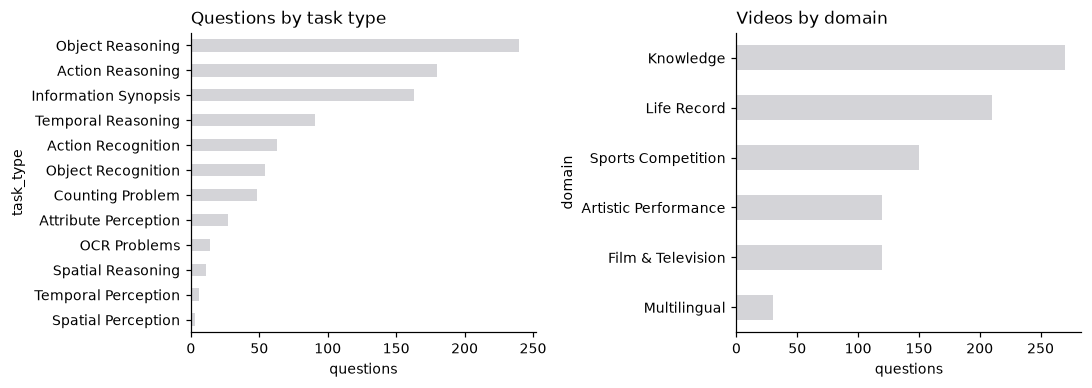

,questions,share
task_type,,
Object Reasoning,240,26.7%
Action Reasoning,180,20.0%
Information Synopsis,163,18.1%
Temporal Reasoning,91,10.1%
Action Recognition,63,7.0%
Object Recognition,54,6.0%
Counting Problem,48,5.3%
Attribute Perception,27,3.0%
OCR Problems,14,1.6%


In [4]:
tasks = long.task_type.value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
tasks.sort_values().plot.barh(ax=ax1, color=MUTED)
ax1.set_title("Questions by task type", loc="left")
ax1.set_xlabel("questions")
long.domain.value_counts().sort_values().plot.barh(ax=ax2, color=MUTED)
ax2.set_title("Videos by domain", loc="left")
ax2.set_xlabel("questions")
plt.tight_layout(); plt.show()
tasks.to_frame("questions").assign(share=lambda d: (d.questions / len(long)).map("{:.1%}".format))

## 3. How long are the videos, really?

Video-MME *defines* the long band as 30–60 minutes. Measured from the files on
disk rather than taken on trust.

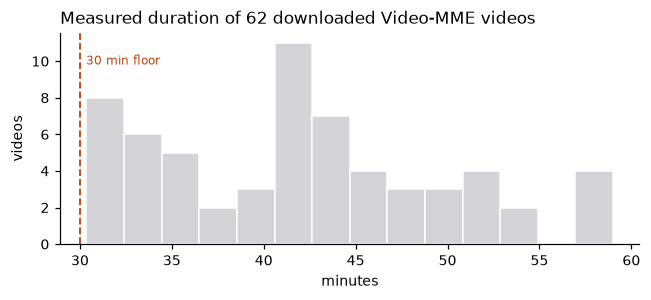

,minutes
count,62.0
mean,42.1
std,7.9
min,30.4
25%,34.8
50%,42.4
75%,46.8
max,59.0


In [5]:
import subprocess

def duration_minutes(path: Path) -> float | None:
    out = subprocess.run(
        ["ffprobe", "-v", "error", "-show_entries", "format=duration",
         "-of", "csv=p=0", str(path)],
        capture_output=True, text=True).stdout.strip()
    return float(out) / 60 if out else None

files = sorted((REPO / ".gist/videos/archive").glob("videomme-*.mp4"))
durations = pd.Series(
    {f.stem.removeprefix("videomme-"): duration_minutes(f) for f in files}
).dropna()

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.hist(durations, bins=14, color=MUTED, edgecolor="white")
ax.axvline(30, color=ACCENT, lw=1.2, ls="--")
ax.annotate("30 min floor", (30, ax.get_ylim()[1] * 0.85), color=ACCENT, fontsize=8,
            xytext=(4, 0), textcoords="offset points")
ax.set_xlabel("minutes"); ax.set_ylabel("videos")
ax.set_title(f"Measured duration of {len(durations)} downloaded Video-MME videos", loc="left")
plt.tight_layout(); plt.show()
durations.describe().round(1).to_frame("minutes")

## 4. How the original subset was actually drawn

This is the part that was documented wrongly for a long time. The repository
claimed the questions were "filtered to those requiring audio and video". They
were not.

In [6]:
pool_old = load_pool("videomme_av_all.json")
chosen = sorted(int(r["video_id"]) for r in {r["video_id"]: r for r in pool_old}.values())
block = range(chosen[0], chosen[-1] + 1)
gaps = [v for v in block if v not in chosen]

print(f"{len(chosen)} videos, {len(pool_old)} questions")
print(f"contiguous block: {chosen[0]}–{chosen[-1]}  ({len(list(block))} ids)")
print(f"gaps inside the block: {gaps}")
print(f"those ids exist in the benchmark: "
      f"{all(str(g) in set(long.video_id) for g in gaps)}  <- lost to failed downloads")

18 videos, 51 questions
contiguous block: 867–887  (21 ids)
gaps inside the block: [874, 876, 878]
those ids exist in the benchmark: True  <- lost to failed downloads


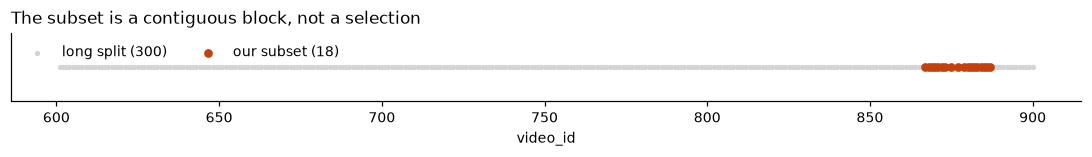

In [7]:
fig, ax = plt.subplots(figsize=(10, 1.5))
all_ids = sorted(long.video_id.astype(int).unique())
ax.scatter(all_ids, [0] * len(all_ids), s=6, color=MUTED, label="long split (300)")
ax.scatter(chosen, [0] * len(chosen), s=22, color=ACCENT, label="our subset (18)")
ax.set_yticks([]); ax.set_xlabel("video_id")
ax.set_title("The subset is a contiguous block, not a selection", loc="left")
ax.legend(frameon=False, loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

## 5. The bias nobody had noticed

Counting questions whose text names speech or sound, using the same keyword test
the scripts use.

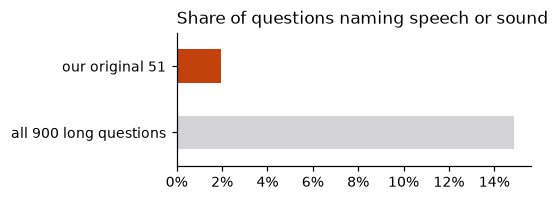

,audio-marker rate
all 900 long questions,15%
our original 51,2%


In [8]:
from analyse_videomme_subset import AUDIO_MARKERS

ids = {r["question_id"] for r in pool_old}
old_sel = long[long.question_id.isin(ids)]
rates = pd.Series({
    "all 900 long questions": long.question.str.contains(AUDIO_MARKERS).mean(),
    "our original 51": old_sel.question.str.contains(AUDIO_MARKERS).mean(),
})

fig, ax = plt.subplots(figsize=(5, 1.9))
rates.plot.barh(ax=ax, color=[MUTED, ACCENT])
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Share of questions naming speech or sound", loc="left")
plt.tight_layout(); plt.show()
rates.map("{:.0%}".format).to_frame("audio-marker rate")

**The sample was audio-poorer than the benchmark it came from.** That bias runs
*against* the method: fewer questions where sound carries the answer means fewer
chances for cross-modal arbitration to matter. A conservative bias is a safe one
to report — but it is the wrong instrument for demonstrating the contribution,
which is what section 6 fixes.

## 6. The balanced pool

`build_videomme_pool.load_long` buckets every question by what its text names, and
`select` picks videos while holding the buckets and the domains in balance.

In [9]:
bucketed = load_long(REPO / "data/videomme-real-subset/hf/videomme/test-00000-of-00001.parquet")
population = bucketed.bucket.value_counts()
population.to_frame("questions in the long split")

excluded 10 unavailable videos


,questions in the long split
bucket,
unmarked,679
audio,124
visual,62
both,5


Only a handful of questions in the whole split name **both** something heard and
something seen. Getting to that number took two corrections to the keyword test:

- **`BOILERPLATE`** — Video-MME phrases many questions as *"according to what is
  shown in the video"*. That is framing, not a claim that the answer is visible;
  it appears on questions answered entirely by narration. Left in, it inflated the
  `both` bucket threefold.
- **`SHOW_AS_NOUN`** — *reality shows*, *competition shows*. The noun, not the verb.

Both are stripped before matching. The corrected count is the honest one.

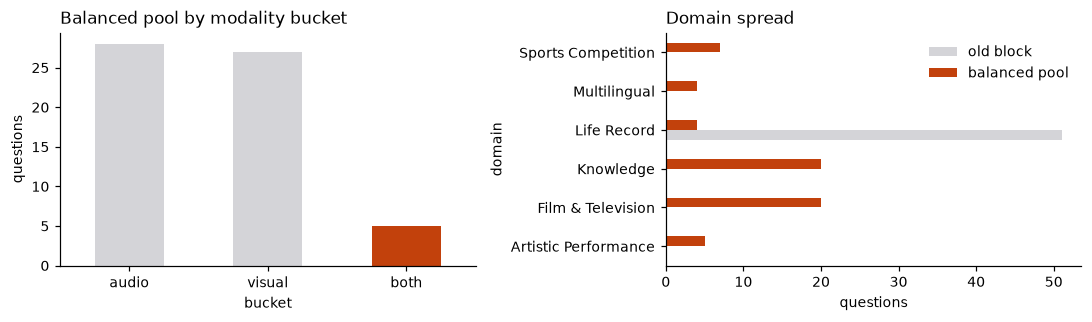

35 videos, 60 questions


,questions,share
bucket,,
audio,28,47%
visual,27,45%
both,5,8%


In [10]:
pool = select(bucketed, target=60, tolerance=6, max_domain_share=0.34)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
counts = pool.bucket.value_counts()
counts.plot.bar(ax=ax1, color=[ACCENT if b == "both" else MUTED for b in counts.index], rot=0)
ax1.set_title("Balanced pool by modality bucket", loc="left"); ax1.set_ylabel("questions")

comparison = pd.DataFrame({
    "old block": old_sel.domain.value_counts(),
    "balanced pool": pool.domain.value_counts(),
}).fillna(0)
comparison.plot.barh(ax=ax2, color=[MUTED, ACCENT])
ax2.set_title("Domain spread", loc="left"); ax2.set_xlabel("questions")
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"{pool.video_id.nunique()} videos, {len(pool)} questions")
counts.to_frame("questions").assign(share=lambda d: (d.questions / len(pool)).map("{:.0%}".format))

The old block was **100% one domain**, Life Record. The balanced pool spans six
with none above a third — so a result can no longer be an artefact of one kind of
video.

## 7. The questions that need both modalities

In [11]:
both = pool[pool.bucket == "both"][["video_id", "domain", "task_type", "question"]]
both.reset_index(drop=True)

,video_id,domain,task_type,question
0,716,Film & Television,Object Reasoning,What can't be inferred from the interview with an Amish woman is shown in the latter p...
1,722,Film & Television,Object Reasoning,"According to the video, does the male interviewee wearing a black suit have a stance t..."
2,722,Film & Television,Action Reasoning,"According to the video, the male interviewee wearing a tight black shirt told a joke a..."
3,724,Film & Television,Information Synopsis,"According to the video, which of the following news items did NOT appear in this news ..."
4,808,Artistic Performance,Object Reasoning,"In the early part of the video, when Sal, the man wearing a black suit and a yellow ti..."


These are the scarce resource and the ones that actually test the contribution:
identify someone by what they are *wearing*, then answer from what they *say*.

Together with the curated corpus — where screening 24 drafted candidates produced
one usable case — this says something about the field rather than about this
project: **questions genuinely requiring both modalities are rare even in
benchmarks marketed as multimodal.**

## 8. Link rot

Video-MME is sourced from YouTube, and uploaders delete or privatise their videos
after a benchmark ships. Dead ids are recorded and excluded at *selection* time, so
a pool's n is known before a GPU is rented rather than discovered after a download.

In [12]:
dead = [ln.split("#")[0].strip() for ln in
        (REPO / "data/eval/videomme-unavailable.txt").read_text().splitlines()
        if ln.strip() and not ln.startswith("#")]
archive = REPO / ".gist/videos/archive"
on_disk = {p.stem.removeprefix("videomme-") for p in archive.glob("videomme-*.mp4")}

rows = []
for name in ("videomme_av6.json", "videomme_av_all.json", "videomme_long.json",
             "videomme_balanced.json"):
    p = load_pool(name)
    if p is None:
        continue
    vids = {r["videoID"] for r in p}
    gone = vids & set(dead)
    rows.append({"pool": name, "questions": len(p), "videos": len(vids),
                 "downloaded": len(vids & on_disk), "dead": len(gone),
                 "questions lost": sum(1 for r in p if r["videoID"] in gone)})
pd.DataFrame(rows).set_index("pool")

,questions,videos,downloaded,dead,questions lost
pool,,,,,
videomme_av6.json,18,6,6,0,0
videomme_av_all.json,51,18,18,0,0
videomme_long.json,60,21,18,3,9
videomme_balanced.json,60,35,31,1,1


A **dead** video caps a pool's n permanently; an **unfetched** one is a download
away. Worth knowing which before renting a GPU.

---

## What this notebook is for

It renders the selection logic so a reader can see the distributions rather than
take them on trust. The committed markdown report at `reports/videomme-subset.md`
is the same analysis in text form, produced by the same functions, and is what CI
and the pod runners read.